# 01 — Titanic Exploratory Data Analysis

This notebook loads the Titanic dataset **once** through seaborn, saves `analytics/titanic.csv`, and then uses only that CSV.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = Path(".").resolve()
if (BASE / "analytics").exists():
    ANALYTICS = BASE / "analytics"
else:
    ANALYTICS = BASE

CHARTS = ANALYTICS / "outputs" / "charts"
METRICS = ANALYTICS / "outputs" / "metrics"
CHARTS.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)
CSV_PATH = ANALYTICS / "titanic.csv"
print("Analytics folder:", ANALYTICS)


Analytics folder: C:\Users\vleel\OneDrive\Desktop\iitp\zepto-data-ai-platform\analytics


## 1. Data profiling

Load Titanic once through seaborn, persist the committed snapshot immediately, and reload that CSV for every subsequent analysis step.

In [2]:
raw = sns.load_dataset("titanic")
raw.to_csv(CSV_PATH, index=False)
print("Saved Titanic snapshot to", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print("Loaded later analysis frame from CSV only.")
print("shape:", df.shape)
print("\n--- df.info() ---")
df.info()
print("\n--- df.describe() ---")
display_desc = df.describe(include="all")
display_desc


Saved Titanic snapshot to C:\Users\vleel\OneDrive\Desktop\iitp\zepto-data-ai-platform\analytics\titanic.csv
Loaded later analysis frame from CSV only.
shape: (891, 15)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtype

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct,
})
missing_tbl = missing_tbl[missing_tbl["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Missing values for every affected column:")
missing_tbl


Missing values for every affected column:


,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


### Missing-data rules used in this EDA copy

- **less than 5%** → drop rows (`embarked`, `embark_town` are typically ~0.2%).
- **5% to 30%** → impute (`age` is typically ~20%; we impute the median).
- **very high missingness** → decide explicitly. `deck` is usually ~77% missing. Dropping the column would throw away a potentially informative cabin signal, but imputing it as if it were MAR would invent a dense category. We **keep the column and encode missing as `Unknown`**.

These EDA imputations are for exploratory charts only. The ML notebook uses a sklearn pipeline fitted on training data so there is no leakage from this demonstration.

In [4]:
eda = df.copy()

# < 5% missing: drop rows
low_missing_cols = [c for c in ["embarked", "embark_town"] if c in eda.columns]
eda = eda.dropna(subset=[c for c in low_missing_cols if eda[c].isna().mean() < 0.05])

# 5% to 30%: impute age with median
age_pct = df["age"].isna().mean() * 100
print(f"age missing percent in original CSV: {age_pct:.2f}")
if 5 <= age_pct <= 30:
    eda["age"] = eda["age"].fillna(eda["age"].median())
    print("Imputed age with median because missingness is between 5% and 30%.")
elif age_pct < 5:
    eda = eda.dropna(subset=["age"])
    print("Dropped age-missing rows because missingness is < 5%.")
else:
    print("Age missingness is outside the 5-30% band; see justification cells.")

# very high: encode deck missingness
if "deck" in eda.columns:
    deck_pct = df["deck"].isna().mean() * 100
    print(f"deck missing percent in original CSV: {deck_pct:.2f}")
    eda["deck"] = eda["deck"].astype("object").fillna("Unknown")
    print("Encoded missing deck as 'Unknown' rather than dropping the column or fabricating a typical deck.")

print("EDA frame shape after missing-value handling:", eda.shape)
eda.head()


age missing percent in original CSV: 19.87
Imputed age with median because missingness is between 5% and 30%.
deck missing percent in original CSV: 77.22
Encoded missing deck as 'Unknown' rather than dropping the column or fabricating a typical deck.
EDA frame shape after missing-value handling: (889, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


## 2. Univariate analysis — age and fare

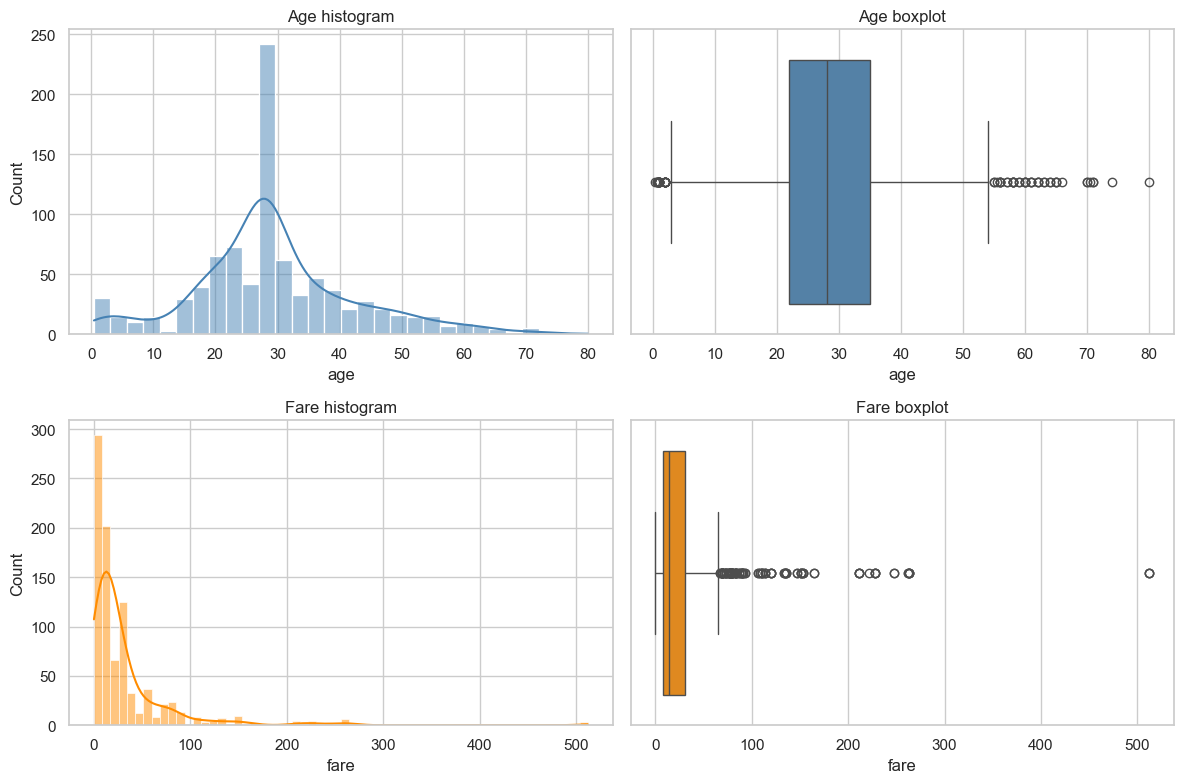

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(eda["age"].dropna(), kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age histogram")
sns.boxplot(x=eda["age"], ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Age boxplot")
sns.histplot(eda["fare"].dropna(), kde=True, ax=axes[1, 0], color="darkorange")
axes[1, 0].set_title("Fare histogram")
sns.boxplot(x=eda["fare"], ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Fare boxplot")
fig.tight_layout()
fig.savefig(CHARTS / "univariate_age_fare.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
def iqr_outlier_count(series: pd.Series) -> dict:
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    return {
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower": lower, "upper": upper,
        "n_outliers": int(mask.sum()),
    }

age_out = iqr_outlier_count(eda["age"])
fare_out = iqr_outlier_count(eda["fare"])
print("Age IQR outliers:", age_out)
print("Fare IQR outliers:", fare_out)

fare = eda["fare"].dropna()
fare_mean = fare.mean()
fare_median = fare.median()
fare_mode = fare.mode().iloc[0]
print(f"fare mean={fare_mean:.4f}")
print(f"fare median={fare_median:.4f}")
print(f"fare mode={fare_mode:.4f}")

if fare_mean > fare_median > fare_mode:
    skew_note = "right-skewed (mean > median > mode)"
elif fare_mean < fare_median < fare_mode:
    skew_note = "left-skewed (mean < median < mode)"
else:
    skew_note = "approximate symmetry or mixed relationship among mean/median/mode"
print("Fare skewness based on mean/median/mode:", skew_note)


Age IQR outliers: {'q1': np.float64(22.0), 'q3': np.float64(35.0), 'iqr': np.float64(13.0), 'lower': np.float64(2.5), 'upper': np.float64(54.5), 'n_outliers': 65}
Fare IQR outliers: {'q1': np.float64(7.8958), 'q3': np.float64(31.0), 'iqr': np.float64(23.1042), 'lower': np.float64(-26.7605), 'upper': np.float64(65.6563), 'n_outliers': 114}
fare mean=32.0967
fare median=14.4542
fare mode=8.0500
Fare skewness based on mean/median/mode: right-skewed (mean > median > mode)


## 3. Bivariate analysis — survival by sex, pclass, and both

Boolean masking is used instead of relying only on `groupby`.

In [7]:
survived = eda["survived"] == 1
female = eda["sex"] == "female"
male = eda["sex"] == "male"

print("Survival rate overall:", survived.mean())
print("Survival rate female (boolean mask):", eda.loc[female, "survived"].mean())
print("Survival rate male (boolean mask):", eda.loc[male, "survived"].mean())

for pclass in sorted(eda["pclass"].dropna().unique()):
    mask = eda["pclass"] == pclass
    print(f"Survival rate pclass={pclass}:", eda.loc[mask, "survived"].mean())

print("\nSurvival rate by sex AND pclass (boolean masks):")
rows = []
for sex_label, sex_mask in [("female", female), ("male", male)]:
    for pclass in sorted(eda["pclass"].dropna().unique()):
        mask = sex_mask & (eda["pclass"] == pclass)
        rate = eda.loc[mask, "survived"].mean()
        n = int(mask.sum())
        rows.append({"sex": sex_label, "pclass": int(pclass), "n": n, "survival_rate": rate})
        print(f"  {sex_label}, pclass={pclass}, n={n}, rate={rate:.4f}")

sex_pclass_tbl = pd.DataFrame(rows)
sex_pclass_tbl.to_csv(METRICS / "eda_survival_sex_pclass.csv", index=False)
sex_pclass_tbl


Survival rate overall: 0.38245219347581555
Survival rate female (boolean mask): 0.7403846153846154
Survival rate male (boolean mask): 0.18890814558058924
Survival rate pclass=1: 0.6261682242990654
Survival rate pclass=2: 0.47282608695652173
Survival rate pclass=3: 0.24236252545824846

Survival rate by sex AND pclass (boolean masks):
  female, pclass=1, n=92, rate=0.9674
  female, pclass=2, n=76, rate=0.9211
  female, pclass=3, n=144, rate=0.5000
  male, pclass=1, n=122, rate=0.3689
  male, pclass=2, n=108, rate=0.1574
  male, pclass=3, n=347, rate=0.1354


,sex,pclass,n,survival_rate
0,female,1,92,0.967391
1,female,2,76,0.921053
2,female,3,144,0.500000
3,male,1,122,0.368852
4,male,2,108,0.157407
5,male,3,347,0.135447


## 4. Correlation on exactly six columns

Columns: `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`. Do **not** include `adult_male` or `alone`.

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


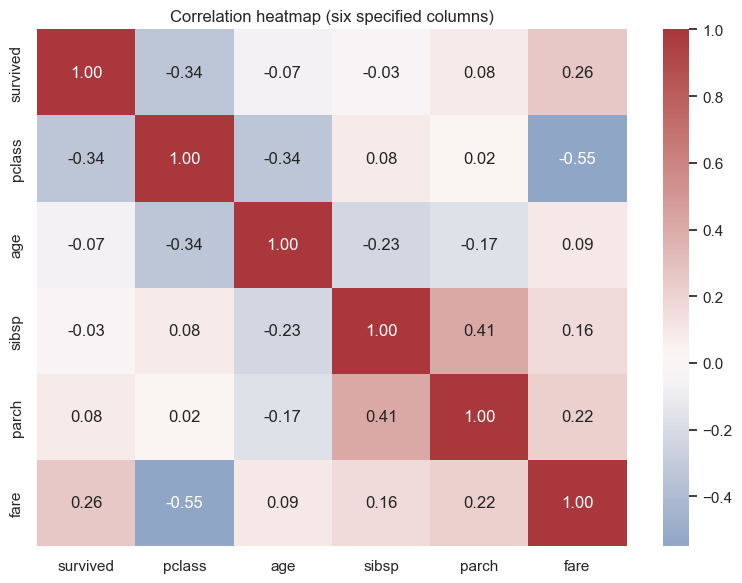

Top two absolute off-diagonal correlations:
  fare vs pclass: abs=0.5482, signed=-0.5482
  parch vs sibsp: abs=0.4145, signed=0.4145


In [8]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = eda[corr_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation heatmap (six specified columns)")
fig.tight_layout()
fig.savefig(CHARTS / "correlation_heatmap_six_cols.png", dpi=150, bbox_inches="tight")
plt.show()

abs_corr = corr.abs().to_numpy().copy()
np.fill_diagonal(abs_corr, 0)
abs_corr_df = pd.DataFrame(abs_corr, index=corr.index, columns=corr.columns)
stacked = abs_corr_df.unstack().sort_values(ascending=False)
# each pair appears twice; keep unique unordered pairs
seen = set()
top_pairs = []
for (a, b), value in stacked.items():
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    top_pairs.append((key, value, corr.loc[a, b]))
    if len(top_pairs) == 2:
        break

print("Top two absolute off-diagonal correlations:")
for key, abs_v, signed in top_pairs:
    print(f"  {key[0]} vs {key[1]}: abs={abs_v:.4f}, signed={signed:.4f}")


### Interpretation of the calculated correlations

The preceding calculation identifies the two largest absolute off-diagonal values from exactly the six required columns. In this saved Titanic snapshot, `pclass` and `fare` have the strongest relationship (approximately **-0.548**): a higher numeric class, meaning third class, is associated with a lower fare. The second strongest pair is `sibsp` and `parch` (approximately **+0.415**), which suggests that passengers travelling with siblings/spouses also more often travelled with parents/children. These are associations in this dataset, not causal effects.


## 5. Multivariate analysis — four distinct charts

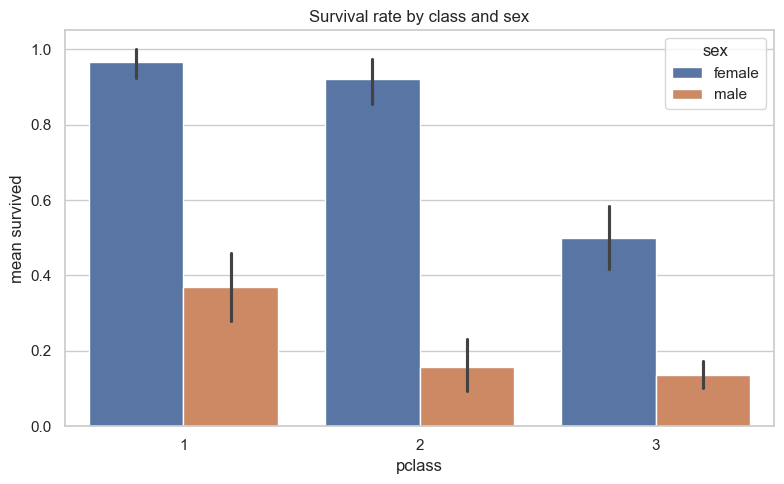

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=eda, x="pclass", y="survived", hue="sex", ax=ax)
ax.set_title("Survival rate by class and sex")
ax.set_ylabel("mean survived")
fig.tight_layout()
fig.savefig(CHARTS / "mv1_survival_class_sex.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** This chart compares survival rate with passenger class and sex. First-class women have the highest visible survival rate, while third-class men have the lowest. The sex split remains clear within each class, suggesting that both class and sex are associated with survival. Because this is observational data, the bars do not establish causal effects.

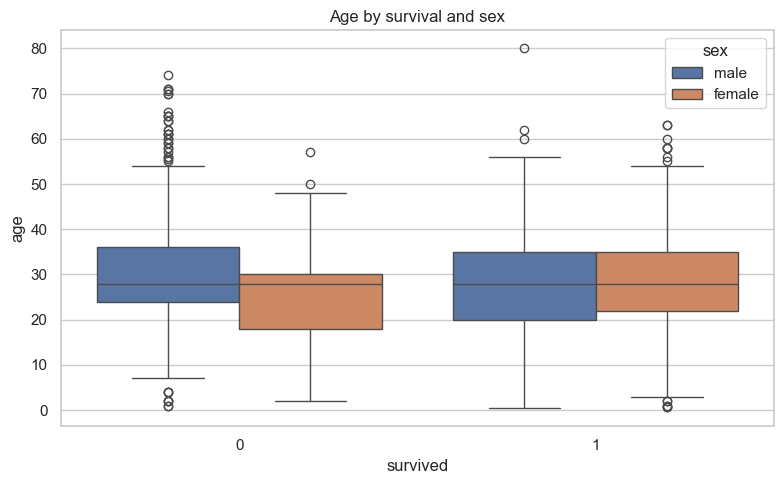

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=eda, x="survived", y="age", hue="sex", ax=ax)
ax.set_title("Age by survival and sex")
fig.tight_layout()
fig.savefig(CHARTS / "mv2_age_survival_sex.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** This boxplot compares age distributions by survival outcome and sex. The groups overlap substantially, so age alone is not a strong separator of survival. Differences by sex are more visually pronounced than shifts in age, and older outliers occur in both outcomes. Median-imputed ages should also make fine-grained age differences cautious to interpret.

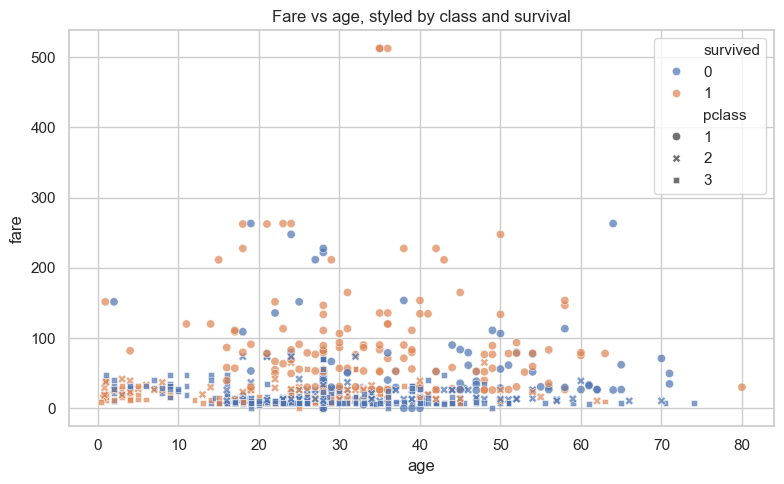

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=eda, x="age", y="fare", hue="survived", style="pclass", alpha=0.7, ax=ax)
ax.set_title("Fare vs age, styled by class and survival")
fig.tight_layout()
fig.savefig(CHARTS / "mv3_fare_age_survival_class.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** The scatterplot compares age and fare, with survival shown by colour and class by marker style. High fares cluster most visibly among first-class passengers, while low-fare third-class passengers dominate the lower part of the plot. Survival outcomes remain mixed at many ages, whereas fare and class show more separation. The large fare outliers compress the lower-fare region, so this visual should be read alongside summary statistics.

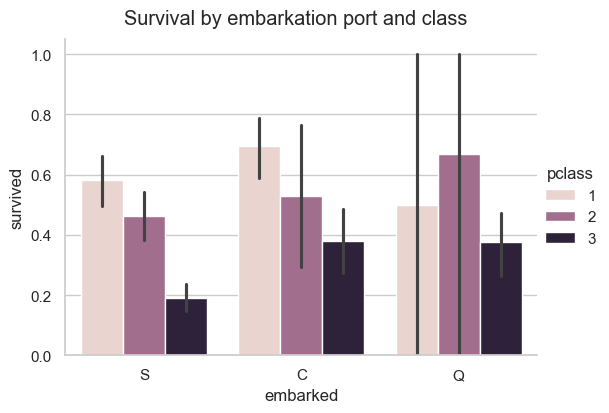

In [12]:
fig = sns.catplot(
    data=eda, x="embarked", y="survived", hue="pclass", kind="bar", height=4, aspect=1.4
)
fig.fig.suptitle("Survival by embarkation port and class", y=1.03)
fig.savefig(CHARTS / "mv4_survival_embarked_class.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** These grouped bars compare survival rate across embarkation ports and passenger classes. The apparent port-level differences change when class is shown, indicating that class composition is an important confounder. Cherbourg's pattern includes a relatively strong first-class survival bar, but that does not mean the port itself caused survival. The small number of observations in some port-class groups is an additional limitation.

## 6. Standardization demonstration (EDA only)

Z-score standardize `age` and `fare` to show mean/std before vs after. **Do not** reuse these transformed columns as leaked features in the ML notebook. Modeling fits `StandardScaler` on the training fold only.

In [13]:
demo = eda[["age", "fare"]].copy()
before = pd.DataFrame({
    "mean_before": demo.mean(),
    "std_before": demo.std(ddof=0),
})
z = (demo - demo.mean()) / demo.std(ddof=0)
after = pd.DataFrame({
    "mean_after": z.mean(),
    "std_after": z.std(ddof=0),
})
std_tbl = pd.concat([before, after], axis=1)
print(std_tbl)
print("After z-score, means are ~0 and standard deviations are ~1.")
print("This transformation is NOT written back into titanic.csv and is NOT used by 02_modeling.ipynb.")
std_tbl.to_csv(METRICS / "eda_standardization_demo.csv")
std_tbl


      mean_before  std_before    mean_after  std_after
age     29.315152   12.977627  2.717486e-16        1.0
fare    32.096681   49.669545  1.398706e-16        1.0
After z-score, means are ~0 and standard deviations are ~1.
This transformation is NOT written back into titanic.csv and is NOT used by 02_modeling.ipynb.


,mean_before,std_before,mean_after,std_after
age,29.315152,12.977627,2.717486e-16,1.0
fare,32.096681,49.669545,1.398706e-16,1.0
